In [1]:

# STUDENT DROPOUT PREDICTION - COMPLETE PREPROCESSING

# Cell 1: Mount Google Drive and Setup
from google.colab import drive
drive.mount('/content/drive')

# Create project folders
!mkdir -p /content/drive/MyDrive/student-dropout-project1/
!mkdir -p /content/drive/MyDrive/student-dropout-project1/data
!mkdir -p /content/drive/MyDrive/student-dropout-project1/models
!mkdir -p /content/drive/MyDrive/student-dropout-project1/notebooks
!mkdir -p /content/drive/MyDrive/student-dropout-project1/csv_exports

print("✅ Google Drive mounted and folders created")

Mounted at /content/drive
✅ Google Drive mounted and folders created


Install and Import Libraries

In [2]:
# Cell 2: Install and Import Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import joblib
import warnings
import os
import zipfile
from google.colab import files

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" All libraries imported successfully!")

 All libraries imported successfully!


 Upload Dataset

In [3]:
# Cell 3: Upload Dataset

uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n File uploaded: {filename}")

# Load the dataset
df = pd.read_csv(filename)
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saving data.csv to data.csv

 File uploaded: data.csv

Dataset shape: 4424 rows × 34 columns


Initial Data Inspection

In [4]:
# Cell 4: Initial Data Inspection

# Display first few rows
print("\n First 5 rows:")
print(df.head())

# Data types
print("\n Data Types:")
print(df.dtypes)

# Missing values
print("\n Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': round(missing_pct, 2)
})
missing_cols = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print(" No missing values found!")

# Basic statistics
print("\n Statistical Summary:")
print(df.describe())

# Target distribution
print("\n Target Variable Distribution:")
target_counts = df['Target'].value_counts()
print(target_counts)
print(f"\nPercentages:")
print(round(df['Target'].value_counts(normalize=True) * 100, 2))


 First 5 rows:
   Marital status  Application mode  Application order  Course  \
0               1                 8                  5     2.0   
1               1                 6                  1    11.0   
2               1                 1                  5     5.0   
3               1                 8                  2    15.0   
4               2                12                  1     3.0   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  \
0                    13.0                    10.0                  6.0   
1                 

Visualize Target Distribution

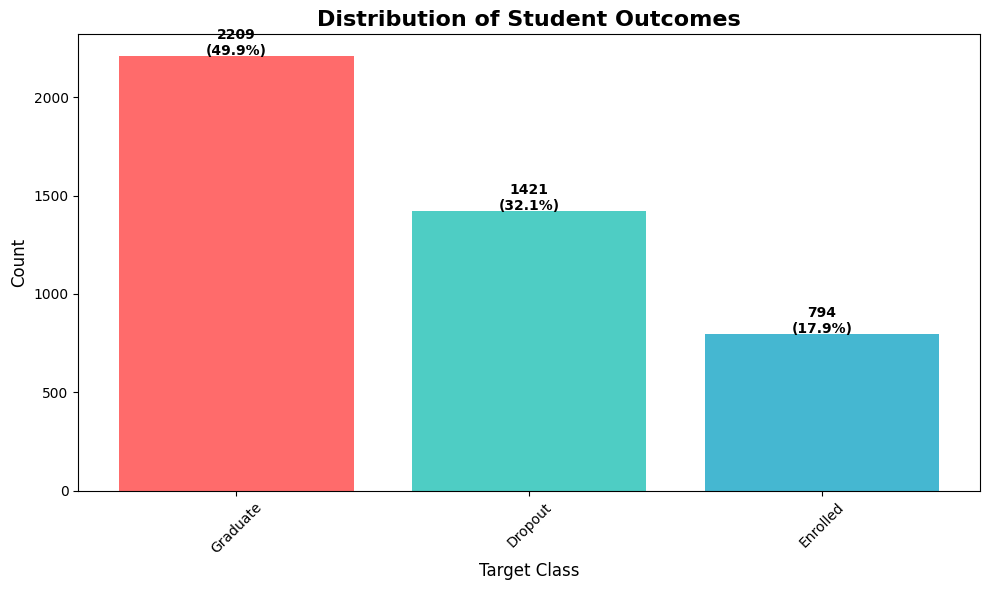

Saved: target_distribution.png


In [5]:
# Cell 5: Visualize Target Distribution
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(target_counts.index, target_counts.values, color=colors)
plt.title('Distribution of Student Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Target Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}\n({height/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300)
plt.show()
print("Saved: target_distribution.png")

 Handle Duplicates

In [6]:
# Cell 6: Handle Duplicates


duplicates = df.duplicated().sum()
print(f"\n Exact duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f" Removed {duplicates} duplicate rows")
    print(f" New shape: {df.shape}")
else:
    print(" No duplicates found!")


 Exact duplicate rows: 0
 No duplicates found!


Feature Engineering

In [8]:
# Cell 7: Feature Engineering


# Create a copy for feature engineering
df_fe = df.copy()
original_cols = df.shape[1]

print("\n Creating Academic Performance Features...")

# Success Rate (approved/enrolled) - avoid division by zero
df_fe['success_rate_sem1'] = df_fe['Curricular units 1st sem (approved)'] / df_fe['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_fe['success_rate_sem2'] = df_fe['Curricular units 2nd sem (approved)'] / df_fe['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df_fe['success_rate_sem1'] = df_fe['success_rate_sem1'].clip(0, 1)
df_fe['success_rate_sem2'] = df_fe['success_rate_sem2'].clip(0, 1)
print("Created: success_rate_sem1, success_rate_sem2")

# Grade Improvement
df_fe['grade_improvement'] = df_fe['Curricular units 2nd sem (grade)'] - df_fe['Curricular units 1st sem (grade)']
print("Created: grade_improvement")

# Total Workload
df_fe['total_workload'] = df_fe['Curricular units 1st sem (enrolled)'] + df_fe['Curricular units 2nd sem (enrolled)']
print("Created: total_workload")

# Failure Rate
df_fe['failure_rate_sem1'] = (df_fe['Curricular units 1st sem (enrolled)'] - df_fe['Curricular units 1st sem (approved)']) / df_fe['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_fe['failure_rate_sem2'] = (df_fe['Curricular units 2nd sem (enrolled)'] - df_fe['Curricular units 2nd sem (approved)']) / df_fe['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df_fe['failure_rate_sem1'] = df_fe['failure_rate_sem1'].clip(0, 1)
df_fe['failure_rate_sem2'] = df_fe['failure_rate_sem2'].clip(0, 1)
print("Created: failure_rate_sem1, failure_rate_sem2")

# Credits Utilization
df_fe['credits_utilization_sem1'] = df_fe['Curricular units 1st sem (credited)'] / df_fe['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_fe['credits_utilization_sem2'] = df_fe['Curricular units 2nd sem (credited)'] / df_fe['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df_fe['credits_utilization_sem1'] = df_fe['credits_utilization_sem1'].clip(0, 1)
df_fe['credits_utilization_sem2'] = df_fe['credits_utilization_sem2'].clip(0, 1)
print("Created: credits_utilization_sem1, credits_utilization_sem2")

print("\n Creating Economic & Demographic Features...")

# Age groups
df_fe['age_group'] = pd.cut(df_fe['Age at enrollment'],
                           bins=[0, 20, 25, 30, 100],
                           labels=['18-20', '21-25', '26-30', '30+'])
print("Created: age_group")

# Family support score
df_fe['family_support'] = (
    (df_fe['Scholarship holder'] * 2) +
    (df_fe['Tuition fees up to date']) +
    (1 - df_fe['Debtor']) +
    (df_fe['Displaced'] * 0.5)
)
print(" Created: family_support")

# Parents education average
df_fe['parents_education'] = (df_fe['Mother\'s qualification'] + df_fe['Father\'s qualification']) / 2
print(" Created: parents_education")

print("\nCreating Interaction Features...")

# Academic Performance Score
df_fe['academic_performance_score'] = (
    df_fe['Curricular units 1st sem (grade)'] * df_fe['success_rate_sem1'] +
    df_fe['Curricular units 2nd sem (grade)'] * df_fe['success_rate_sem2']
) / 2
print(" Created: academic_performance_score")

# Risk Score (higher = more at risk)
df_fe['risk_score'] = (
    (1 - df_fe['success_rate_sem2']) * 3 +
    (1 - df_fe['Tuition fees up to date']) * 2 +
    df_fe['Debtor'] * 2 +
    (df_fe['Age at enrollment'] > 25).astype(int) * 1
)
print(" Created: risk_score")

print(f"\nFeature Engineering Summary:")
print(f"   Original features: {original_cols}")
print(f"   New features: {df_fe.shape[1] - original_cols}")
print(f"   Total features: {df_fe.shape[1]}")


 Creating Academic Performance Features...
Created: success_rate_sem1, success_rate_sem2
Created: grade_improvement
Created: total_workload
Created: failure_rate_sem1, failure_rate_sem2
Created: credits_utilization_sem1, credits_utilization_sem2

 Creating Economic & Demographic Features...
Created: age_group
 Created: family_support
 Created: parents_education

Creating Interaction Features...
 Created: academic_performance_score
 Created: risk_score

Feature Engineering Summary:
   Original features: 34
   New features: 13
   Total features: 47


 Handle Missing Values in Engineered Dataset

In [9]:
# Cell 8: Handle Missing Values


# Check missing values in engineered dataset
missing_new = df_fe.isnull().sum()
missing_new = missing_new[missing_new > 0]

if len(missing_new) > 0:
    print(f"\n Found {len(missing_new)} columns with missing values:")
    print(missing_new)

    # Fill numeric columns with median
    num_cols = df_fe.select_dtypes(include=[np.number]).columns
    for col in missing_new.index:
        if col in num_cols:
            median_val = df_fe[col].median()
            df_fe[col].fillna(median_val, inplace=True)
            print(f" Filled '{col}' with median: {median_val:.2f}")

    # Fill categorical with mode
    cat_cols = df_fe.select_dtypes(include=['object', 'category']).columns
    for col in missing_new.index:
        if col in cat_cols:
            mode_val = df_fe[col].mode()[0]
            df_fe[col].fillna(mode_val, inplace=True)
            print(f" Filled '{col}' with mode: {mode_val}")
else:
    print("\n No missing values found in engineered dataset!")


 Found 23 columns with missing values:
Course                                 1
Mother's qualification                 2
Father's qualification                 3
Mother's occupation                    3
Displaced                              2
Tuition fees up to date                1
Age at enrollment                      4
International                          1
Curricular units 1st sem (credited)    2
Curricular units 1st sem (approved)    1
Curricular units 2nd sem (enrolled)    1
success_rate_sem1                      1
success_rate_sem2                      1
total_workload                         1
failure_rate_sem1                      1
failure_rate_sem2                      1
credits_utilization_sem1               2
credits_utilization_sem2               1
age_group                              4
family_support                         3
parents_education                      5
academic_performance_score             2
risk_score                             2
dtype: int64
 Fil

EXPORT PREPROCESSED CSV FILES

In [10]:
# Cell 9: EXPORT PREPROCESSED DATA AS CSV FILES
# 1. FULL PREPROCESSED DATASET (before encoding)
df_preprocessed = df_fe.copy()
df_preprocessed.to_csv('student_dropout_preprocessed_full.csv', index=False)
print(f" Saved: student_dropout_preprocessed_full.csv")
print(f"   Shape: {df_preprocessed.shape}")
print(f"   Features: {df_preprocessed.columns.tolist()[:10]}...")  # Show first 10

 Saved: student_dropout_preprocessed_full.csv
   Shape: (4424, 47)
   Features: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation"]...


 Encode Categorical Variables

In [11]:
# Cell 10: Encode Categorical Variables


# Identify categorical columns
categorical_cols = df_fe.select_dtypes(include=['object', 'category']).columns
categorical_cols = [col for col in categorical_cols if col != 'Target']

print(f"\n Categorical columns to encode: {categorical_cols}")

# One-Hot Encoding
df_encoded = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

print(f"\nAfter one-hot encoding:")
print(f"   Original features: {df_fe.shape[1]}")
print(f"   Encoded features: {df_encoded.shape[1]}")

# Save encoded dataset
df_encoded.to_csv('student_dropout_encoded.csv', index=False)
print(f" Saved: student_dropout_encoded.csv")


 Categorical columns to encode: ['age_group']

After one-hot encoding:
   Original features: 47
   Encoded features: 49
 Saved: student_dropout_encoded.csv


Separate Features and Target

In [12]:
# Cell 11: Separate Features and Target

# Separate features and target
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

print(f"\n Features matrix (X): {X.shape}")
print(f" Target vector (y): {y.shape}")
print(f"\n Target classes: {y.unique()}")

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n Label encoding mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"   {class_name} → {i}")


 Features matrix (X): (4424, 48)
 Target vector (y): (4424,)

 Target classes: ['Dropout' 'Graduate' 'Enrolled']

 Label encoding mapping:
   Dropout → 0
   Enrolled → 1
   Graduate → 2


Train-Test Split

In [13]:
# Cell 12: Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n Training set: {X_train.shape}")
print(f" Test set: {X_test.shape}")

print(f"\n Training set distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    class_name = label_encoder.inverse_transform([u])[0]
    print(f"   {class_name}: {c} samples ({c/len(y_train)*100:.1f}%)")

print(f"\n Test set distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    class_name = label_encoder.inverse_transform([u])[0]
    print(f"   {class_name}: {c} samples ({c/len(y_test)*100:.1f}%)")


 Training set: (3539, 48)
 Test set: (885, 48)

 Training set distribution:
   Dropout: 1137 samples (32.1%)
   Enrolled: 635 samples (17.9%)
   Graduate: 1767 samples (49.9%)

 Test set distribution:
   Dropout: 284 samples (32.1%)
   Enrolled: 159 samples (18.0%)
   Graduate: 442 samples (49.9%)


Handle Imbalanced Data with SMOTE

In [14]:
# Cell 13: Handle Imbalanced Data with SMOTE

print(f"\nOriginal training class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    class_name = label_encoder.inverse_transform([u])[0]
    print(f"   {class_name}: {c} samples")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n SMOTE applied!")
print(f"\n Balanced training class distribution:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    class_name = label_encoder.inverse_transform([u])[0]
    print(f"   {class_name}: {c} samples")


Original training class distribution:
   Dropout: 1137 samples
   Enrolled: 635 samples
   Graduate: 1767 samples

 SMOTE applied!

 Balanced training class distribution:
   Dropout: 1767 samples
   Enrolled: 1767 samples
   Graduate: 1767 samples


Feature Scaling

In [15]:
# Cell 14: Feature Scaling

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print(f"\n Training data scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f" Test data scaled: mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")

# Save scaled datasets as CSV
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
df_train_scaled['Target'] = y_train_balanced
df_train_scaled.to_csv('student_dropout_train.csv', index=False)
print(f" Saved: student_dropout_train.csv")

df_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
df_test_scaled['Target'] = y_test
df_test_scaled.to_csv('student_dropout_test.csv', index=False)
print(f" Saved: student_dropout_test.csv")


 Training data scaled: mean=-0.0000, std=1.0000
 Test data scaled: mean=0.0317, std=1.0497
 Saved: student_dropout_train.csv
 Saved: student_dropout_test.csv


Feature Importance Analysis


 Available features: 48

 Training Random Forest for feature importance...
 Training complete!
 Saved: feature_importance.csv

 Top 15 Most Important Features:
                            feature  importance
                         risk_score    0.082899
                  success_rate_sem2    0.081920
                  failure_rate_sem2    0.072157
         academic_performance_score    0.070750
Curricular units 2nd sem (approved)    0.043276
                  failure_rate_sem1    0.039772
                  success_rate_sem1    0.038778
Curricular units 1st sem (approved)    0.038655
   Curricular units 2nd sem (grade)    0.035611
                     family_support    0.030492
   Curricular units 1st sem (grade)    0.029987
                  Age at enrollment    0.026966
                Mother's occupation    0.025495
                             Course    0.024829
                  grade_improvement    0.024414

 Selected 24 features (those above median importance)
   This is ~50% 

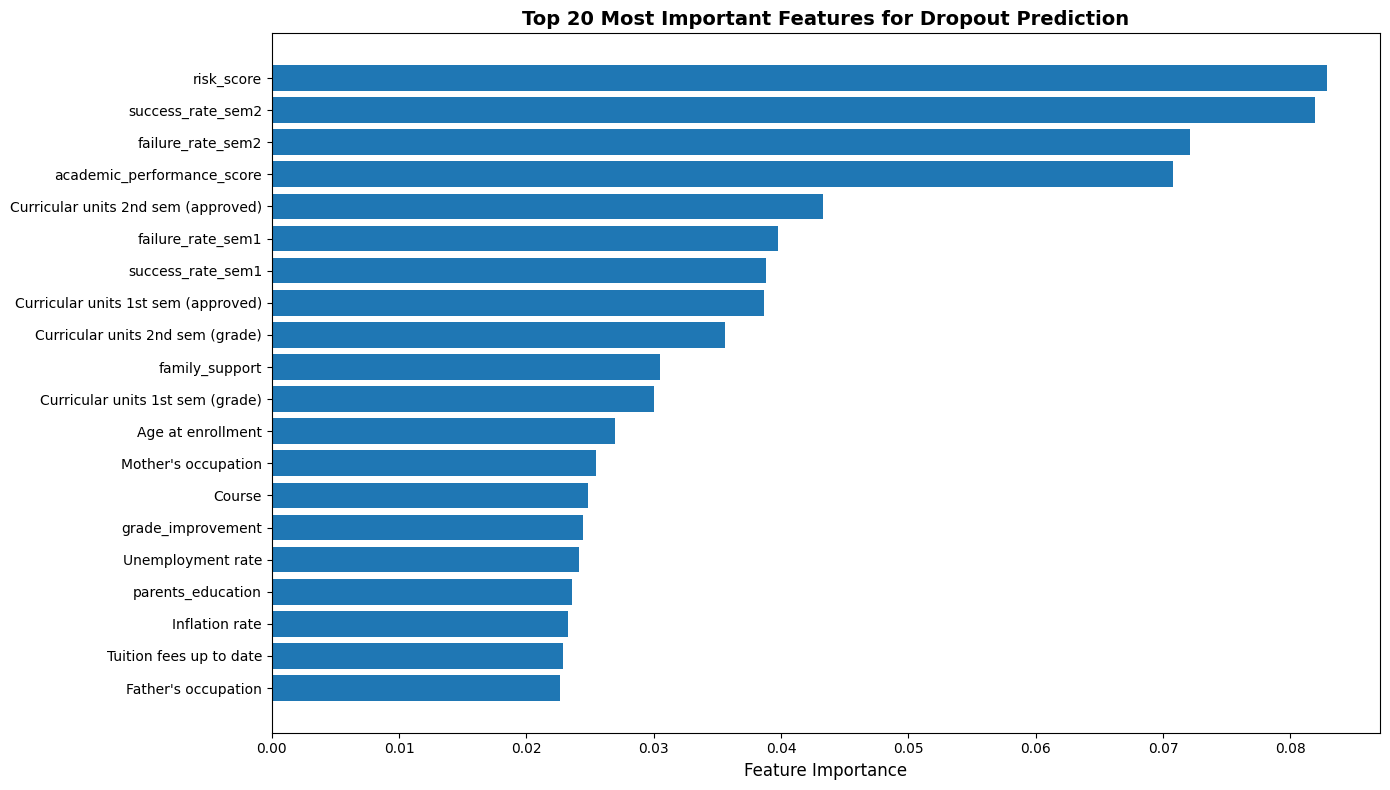

 Saved: feature_importance.png


In [16]:
# Cell 15: Feature Importance Analysis

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

n_features_available = X_train_scaled.shape[1]
print(f"\n Available features: {n_features_available}")

# Train Random Forest
print("\n Training Random Forest for feature importance...")
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train_scaled, y_train_balanced)
print(" Training complete!")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
print(f" Saved: feature_importance.csv")

# Display top features
print(f"\n Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Select features above median importance
selector = SelectFromModel(rf_temp, threshold='median')
X_train_selected = selector.fit_transform(X_train_scaled, y_train_balanced)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()
n_selected = len(selected_features)

print(f"\n Selected {n_selected} features (those above median importance)")
print(f"   This is ~{n_selected/n_features_available*100:.0f}% of all features")

# Save selected features datasets
df_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
df_train_selected['Target'] = y_train_balanced
df_train_selected.to_csv('student_dropout_train_selected.csv', index=False)
print(f" Saved: student_dropout_train_selected.csv")

df_test_selected = pd.DataFrame(X_test_selected, columns=selected_features)
df_test_selected['Target'] = y_test
df_test_selected.to_csv('student_dropout_test_selected.csv', index=False)
print(f" Saved: student_dropout_test_selected.csv")

# Visualize
plt.figure(figsize=(14, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

plt.barh(range(top_n), top_features['importance'].values)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features for Dropout Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: feature_importance.png")

Save All Models and Data Files

In [17]:
# Cell 16: Save All Models and Data Files

# Save to Google Drive
save_path = '/content/drive/MyDrive/student-dropout-project/'

# Save numpy arrays
np.save(f'{save_path}data/X_train_scaled.npy', X_train_scaled)
np.save(f'{save_path}data/X_test_scaled.npy', X_test_scaled)
np.save(f'{save_path}data/y_train.npy', y_train_balanced)
np.save(f'{save_path}data/y_test.npy', y_test)
np.save(f'{save_path}data/X_train_selected.npy', X_train_selected)
np.save(f'{save_path}data/X_test_selected.npy', X_test_selected)

# Save models and encoders
joblib.dump(label_encoder, f'{save_path}models/label_encoder.pkl')
joblib.dump(scaler, f'{save_path}models/scaler.pkl')
joblib.dump(X.columns.tolist(), f'{save_path}models/feature_names.pkl')
joblib.dump(selected_features, f'{save_path}models/selected_features.pkl')
joblib.dump(selector, f'{save_path}models/feature_selector.pkl')

# Copy CSV files to Drive
!cp *.csv /content/drive/MyDrive/student-dropout-project/csv_exports/
!cp *.png /content/drive/MyDrive/student-dropout-project/

print(f" All files saved to Google Drive: {save_path}")

# Save locally in Colab
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_train.npy', y_train_balanced)
np.save('y_test.npy', y_test)
np.save('X_train_selected.npy', X_train_selected)
np.save('X_test_selected.npy', X_test_selected)

joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
joblib.dump(selector, 'feature_selector.pkl')

print("\n All files saved locally in Colab")

cp: target '/content/drive/MyDrive/student-dropout-project/csv_exports/' is not a directory
 All files saved to Google Drive: /content/drive/MyDrive/student-dropout-project/

 All files saved locally in Colab


Create Complete ZIP File

In [18]:
# Cell 17: Create Complete ZIP File

zip_filename = 'student_dropout_complete_data.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add all CSV files
    csv_files = [
        'student_dropout_preprocessed_full.csv',
        'student_dropout_encoded.csv',
        'student_dropout_train.csv',
        'student_dropout_test.csv',
        'student_dropout_train_selected.csv',
        'student_dropout_test_selected.csv',
        'feature_importance.csv'
    ]

    for file in csv_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f" Added CSV: {file}")

    # Add numpy arrays
    numpy_files = ['X_train_scaled.npy', 'X_test_scaled.npy',
                   'y_train.npy', 'y_test.npy',
                   'X_train_selected.npy', 'X_test_selected.npy']

    for file in numpy_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f" Added NPY: {file}")

    # Add model files
    model_files = ['label_encoder.pkl', 'scaler.pkl',
                   'feature_names.pkl', 'selected_features.pkl',
                   'feature_selector.pkl']

    for file in model_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f" Added PKL: {file}")

    # Add images
    image_files = ['target_distribution.png', 'feature_importance.png']
    for file in image_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f" Added PNG: {file}")

print(f"\n ZIP file created: {zip_filename}")
print(f"Size: {os.path.getsize(zip_filename) / 1024 / 1024:.2f} MB")

 Added CSV: student_dropout_preprocessed_full.csv
 Added CSV: student_dropout_encoded.csv
 Added CSV: student_dropout_train.csv
 Added CSV: student_dropout_test.csv
 Added CSV: student_dropout_train_selected.csv
 Added CSV: student_dropout_test_selected.csv
 Added CSV: feature_importance.csv
 Added NPY: X_train_scaled.npy
 Added NPY: X_test_scaled.npy
 Added NPY: y_train.npy
 Added NPY: y_test.npy
 Added NPY: X_train_selected.npy
 Added NPY: X_test_selected.npy
 Added PKL: label_encoder.pkl
 Added PKL: scaler.pkl
 Added PKL: feature_names.pkl
 Added PKL: selected_features.pkl
 Added PKL: feature_selector.pkl
 Added PNG: target_distribution.png
 Added PNG: feature_importance.png

 ZIP file created: student_dropout_complete_data.zip
Size: 41.83 MB


Download ZIP File

In [19]:
# Cell 18: Download ZIP File

files.download(zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>